# Model Trianing 
- Trained Linear Regression model
- Evaluated the model with MAE,RMSE and R2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

In [2]:
df = pd.read_csv("..\data\processed\cleaned_dataset.csv")

In [3]:
df.shape

(1456, 205)

## Data Spilt Train & Validation

In [4]:
# separation of input and output features

#target variable
y= df["SalePrice"]

# Input features
X = df.drop("SalePrice", axis=1)

print("X Shape:", X.shape)
print("y shape:" ,y.shape)

# train-test split
X_train,X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X Shape: (1456, 204)
y shape: (1456,)
X_train shape: (1164, 204)
X_test shape: (292, 204)
y_train shape: (1164,)
y_test shape: (292,)


## 1. Linear Regression

In [23]:
# creating model and training
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# creating model object
linear_pipeline = Pipeline([("scaler", StandardScaler()),("linear", LinearRegression())])

#train the model
linear_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


Linear regression uses the Normal Equation to calculate perfect coefficients to predict the target, which is the price of a house, so some of the features will have more weight/importance in predicting the price.

In [24]:
# predictions
y_pred_linear = linear_pipeline.predict(X_test)

In [8]:
# model evaluation
def score_model(y_test,y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2


In [9]:
linear_scores = score_model(y_test, y_pred_linear)
print("MAE:", linear_scores[0])
print("RMSE:", linear_scores[1])
print("R2 score:", linear_scores[2])

MAE: 17667.970081312513
RMSE: 23700.654178206456
R2 score: 0.8929732782284984


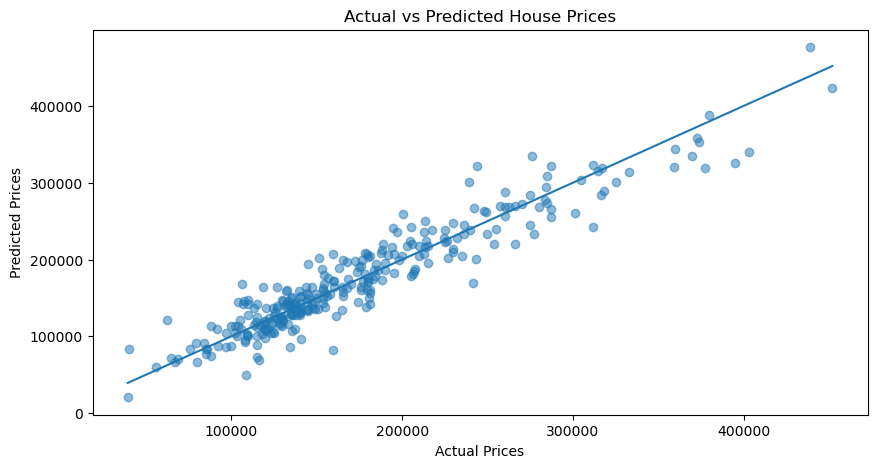

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred_linear, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()])
plt.show()

## 2. Ridge Regession

In [11]:
# Ridge regression (L2 regularization) with Cross-validation
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = np.logspace(-6,6,20)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge_pipeline = Pipeline([("scaler", StandardScaler()),("ridge", ridge)])
ridge_pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,array([1.0000...00000000e+06])
,fit_intercept,True
,scoring,None
,cv,5


In [12]:

y_pred_ridge = ridge_pipeline.predict(X_test)

ridge_scores = score_model(y_test, y_pred_ridge)
print("MAE:", ridge_scores[0])
print("RMSE:", ridge_scores[1])
print("R2 score:", ridge_scores[2])

MAE: 16840.946409357726
RMSE: 23008.38194972876
R2 score: 0.8991342521619294


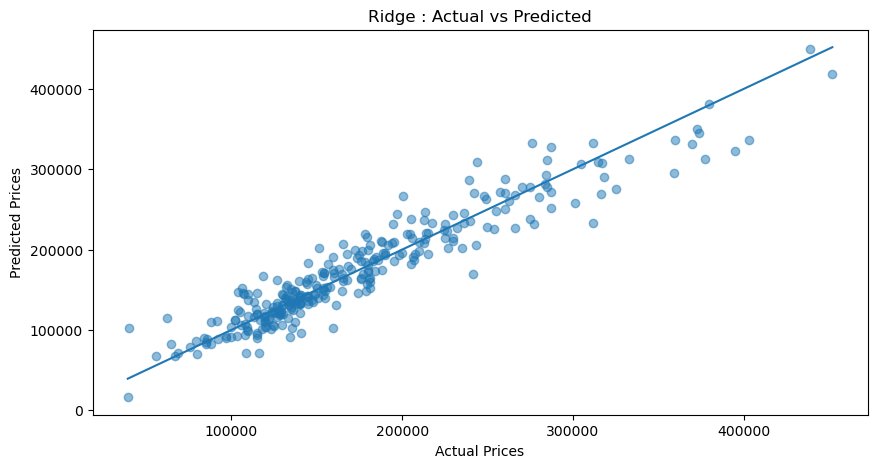

In [28]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred_ridge, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Ridge : Actual vs Predicted")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

## 3. Lasso Regression

In [14]:
# Lasso regression (L1 regularisation)
from sklearn.linear_model import Lasso, LassoCV

alphas = np.logspace(-6,6,100)
lasso = LassoCV(alphas=alphas,cv=5, max_iter=10000)
lasso_pipeline =Pipeline([("Standscaler",StandardScaler()), ("lasso" ,lasso)])
lasso_pipeline.fit(X_train,y_train)

,steps,"[('Standscaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+06])
,fit_intercept,True


In [18]:
y_pred_lasso = lasso_pipeline.predict(X_test)

In [19]:
lasso_scores = score_model(y_test, y_pred_lasso)
print("MAE:", lasso_scores[0])
print("RMSE:", lasso_scores[1])
print("R2 score:", lasso_scores[2])
print("Best alpha: ",lasso_pipeline.named_steps["lasso"].alpha_)

MAE: 16514.478766266377
RMSE: 22354.46070010968
R2 score: 0.9047861885892251
Best alpha:  533.6699231206302


In [83]:
# Analyse Feature selection

# zeroed featues
zeroed_features = np.sum(lasso_pipeline.named_steps["lasso"].coef_ == 0)
print(f" Number of features removed by lasso: {zeroed_features} / {len(lasso_pipeline.named_steps["lasso"].coef_)}")
# 10 top Features
important_features = np.argsort(np.abs(lasso_pipeline.named_steps["lasso"].coef_))[-10:][::-1]
print("Top ten features by coefficent magnitude:")
print(np.array(X_train.columns)[important_features])

 Number of features removed by lasso: 104 / 204
Top ten features by coefficent magnitude:
['GrLivArea' 'OverallQual' 'BsmtFinSF1' 'SaleType_New'
 'Neighborhood_NridgHt' 'MasVnrArea' 'YearBuilt' 'BsmtExposure'
 'TotalBsmtSF' 'LotArea']


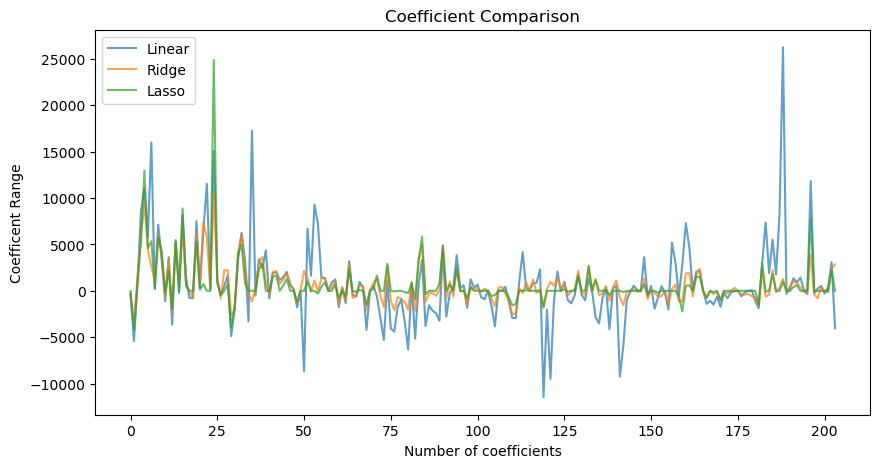

In [26]:
plt.figure(figsize=(10,5))
plt.plot(linear_pipeline.named_steps["linear"].coef_, label="Linear", alpha=0.7)
plt.plot(ridge_pipeline.named_steps["ridge"].coef_, label="Ridge", alpha=0.7)
plt.plot(lasso_pipeline.named_steps["lasso"].coef_, label="Lasso", alpha=0.7)
plt.xlabel("Number of coefficients")
plt.ylabel("Coefficent Range")
plt.legend()
plt.title("Coefficient Comparison")
plt.show()

What does our above graph tell?
This graph shows how the Ridge regression has squeezed the weights or coefficient values. So, giving every feature a chance to have its true impact on predicting our target.
How does it happen? Just by adding the penalty term (lambda * sum of squared coefficients) to the OLS objective function. which will penalise bigger coefficients more by applying the square to them 

## Model Comparisons

In [27]:
# Model Comparisons

results = pd.DataFrame({
    "Model" : ["Linear", "Ridge","Lasso"],
    "MAE" : [linear_scores[0], ridge_scores[0],lasso_scores[0]],
    "RMSE" : [linear_scores[1], ridge_scores[1],lasso_scores[1]],
    "R2" : [linear_scores[2], ridge_scores[2],lasso_scores[2]]
 })
results

,Model,MAE,RMSE,R2
0,Linear,17667.970081,23700.654178,0.892973
1,Ridge,16840.946409,23008.381950,0.899134
2,Lasso,16514.478766,22354.460700,0.904786


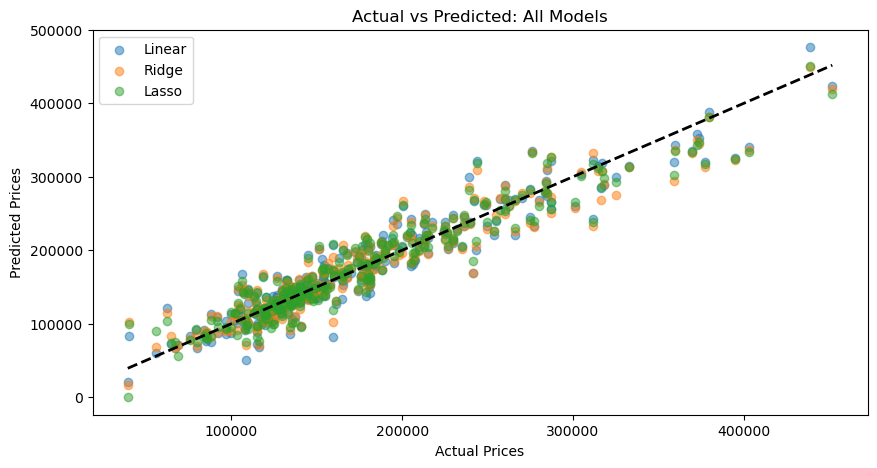

In [50]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_linear, alpha=0.5, label="Linear")
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label="Ridge")
plt.scatter(y_test, y_pred_lasso, alpha=0.5, label="Lasso")
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()], "k--", lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted: All Models")
plt.legend()
plt.show()